In [3]:
import numpy as np
from matplotlib import pyplot as plt
import os
from os import path
import h5py

import sys
sys.path.insert(0, "./radiative_shock/")

from nlte_radiative_shock import NLTERadiativeShock

INFO:RadiativeShock:creating a RadiativeShock calculator...
INFO:RadiativeShock:gamma=1.66667
INFO:RadiativeShock:M0=2
INFO:RadiativeShock:P0=0.0001
INFO:RadiativeShock:downstream (unshocked, left) state: rho=5.45969e-13[g/cc] T=100[K]=8.617333e-06[keV] v=235470[cm/s]
INFO:RadiativeShock:upstream   (shocked, right)  state: rho=1.248126e-12[g/cc] T=207.757[K]=1.790311e-05[keV] v=103021.4[cm/s]
INFO:RadiativeShock:v_shock=34.7631[cm/s]
INFO:RadiativeShock:compression 2.28607
INFO:RadiativeShock:matter ideal gas (gamma=1.66667) dominated compression 2.28576
INFO:RadiativeShock:radiation ideal gas (gamma=4/3) dominated compression 2.91498
INFO:RadiativeShock:calculated mach=(v_shock-v_left)/cs_left=2 while given mach M0=2 err=2.22045e-16
INFO:NLTERadiativeShock:creating a NLTERadiativeShock calculator...


Precursor region
Relaxation region
Discontinuous case: embedded hydrodynamic shock


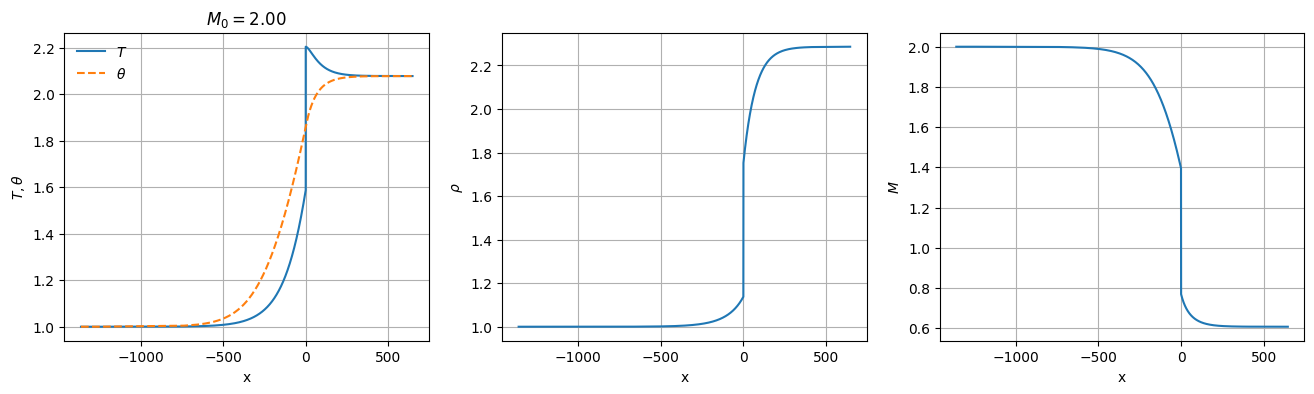

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode


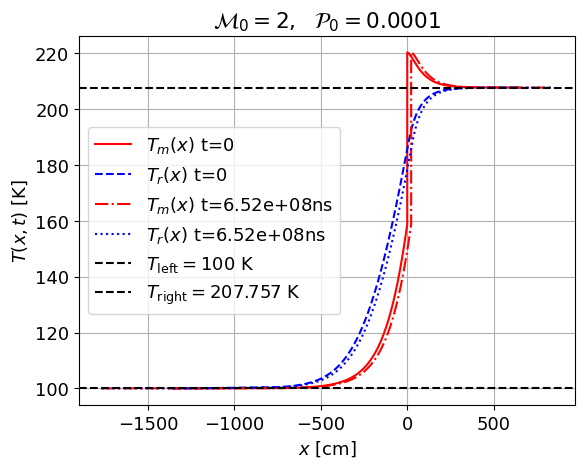

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode


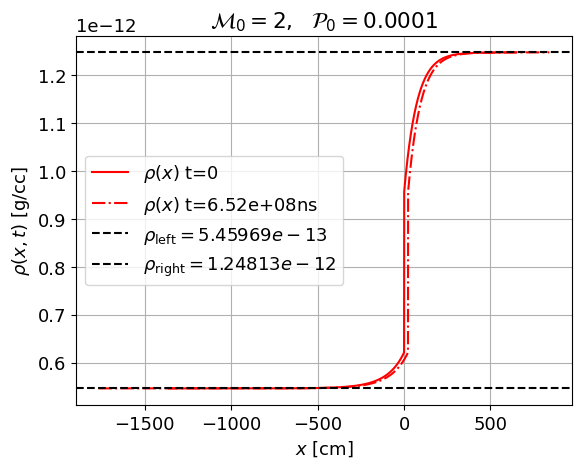

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode


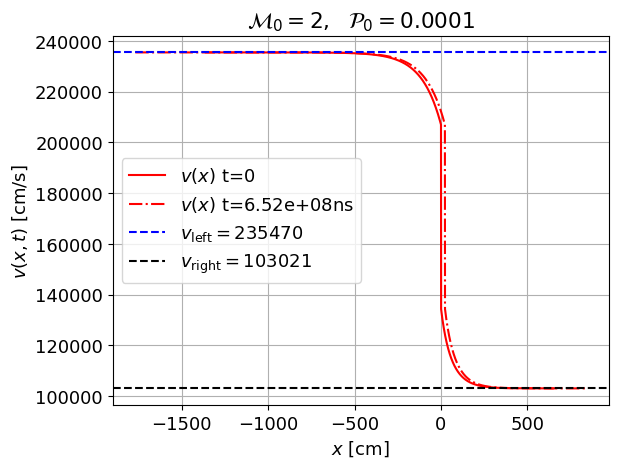

In [4]:
Navog = 6.02214076e23
k_boltz = 1.380649e-16
gas_constant = k_boltz*Navog
molar_mass_H = 1.
solver = NLTERadiativeShock(
    M0=2.,
    gamma=5./3.,
    sigma_ross=lambda T,rho:0.848903,
    sigma_abs=lambda T,rho:3.92664e-5,
    cv=gas_constant/(5./3.-1.)/molar_mass_H,
    rho_left=5.45969e-13,
    v_left=2.3547e5,
    T_left=100.,
    plot_dimensionless=True,
    eps_nlte_solver=0.5e-4,
).plot_profiles()

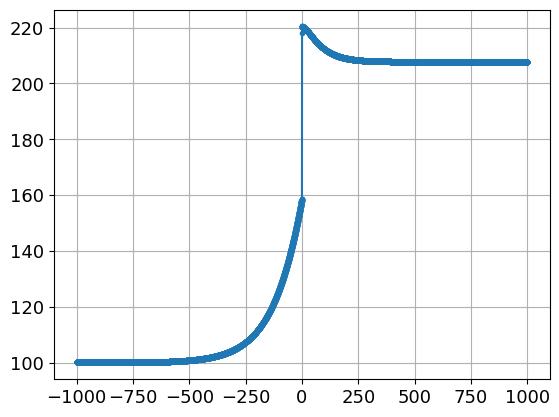

In [5]:
x = np.linspace(-1000, 1000, int(1e4))
sol = solver.solve_profiles(time=0.0, x=x)

plt.plot(x, sol["temperature"], '.-')
plt.grid()
plt.show()

In [13]:
output_files_path = "/home/itamarg/workspace/RICH/output/RadHydroMach2Multigroup_2"
path_to_initial_snap = path.join(output_files_path, f"Mach2_{0}.h5")

snaps = [file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))]
print(snaps)

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))])
num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    print(h5_file.keys())
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])

['Mach2_0.h5']
<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Eg_0', 'Eg_1', 'Eg_2', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


In [7]:
speed_of_light = 2.99792458e10
stefan_boltzman = 5.670374e-5
radiation_constant = 4 * stefan_boltzman / speed_of_light
boltzmann_constant = 1.380649e-16

ev = 1.602176634e-12
kev = 1e3*ev

kev_to_kelvin = kev / boltzmann_constant

G=num_groups
Emin = ev*1e-3
Emax = ev

energy_groups_boundary = np.geomspace(Emin, Emax, G+1)
energy_groups_boundary_kev = energy_groups_boundary / kev
energy_groups_width = np.diff(energy_groups_boundary, n=1)

In [14]:
Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"Mach2_{i*100}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        CMx[i, :] = np.array(h5_file["CMx"])
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

In [15]:
x = np.linspace(-1000, 2000, int(1e5))
sol = solver.solve_profiles(time=0.0, x=x)

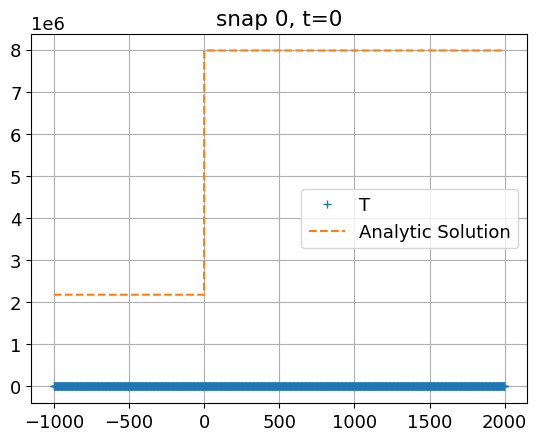

In [16]:
dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    plt.plot(CMx[i, :], Tm[i, :], '+', label="T")
    plt.plot(x, sol['temperature'], '--', label="Analytic Solution")
    # plt.plot(CMx[i, :], Tr[i, :])

    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    # plt.xlim(0, 3.)
    plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()
    

In [38]:
output_files_path = "/home/itamarg/workspace/RICH/output/Mach2_step_2"
path_to_initial_snap = path.join(output_files_path, f"Mach2_{0}.h5")

snaps = [file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))]
print(snaps)

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))])
num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    print(h5_file.keys())
    num_cells = len(np.array(h5_file["Erad"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])

['Mach2_0.h5', 'Mach2_100.h5', 'Mach2_200.h5', 'Mach2_300.h5', 'Mach2_400.h5', 'Mach2_500.h5', 'Mach2_600.h5', 'Mach2_700.h5', 'Mach2_800.h5', 'Mach2_900.h5', 'Mach2_1000.h5', 'Mach2_1100.h5', 'Mach2_1200.h5', 'Mach2_1300.h5', 'Mach2_1400.h5', 'Mach2_1500.h5', 'Mach2_1600.h5', 'Mach2_1700.h5', 'Mach2_1800.h5', 'Mach2_1900.h5', 'Mach2_2000.h5', 'Mach2_2100.h5', 'Mach2_2200.h5', 'Mach2_2300.h5', 'Mach2_2400.h5', 'Mach2_2500.h5', 'Mach2_2600.h5']
<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


In [39]:
speed_of_light = 2.99792458e10
stefan_boltzman = 5.670374e-5
radiation_constant = 4 * stefan_boltzman / speed_of_light
boltzmann_constant = 1.380649e-16

ev = 1.602176634e-12
kev = 1e3*ev

kev_to_kelvin = kev / boltzmann_constant

G=num_groups
Emin = kev*1e-3
Emax = kev*1e3

energy_groups_boundary = np.geomspace(Emin, Emax, G+1)
energy_groups_boundary_kev = energy_groups_boundary / kev
energy_groups_width = np.diff(energy_groups_boundary, n=1)

In [40]:
Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"Mach2_{i*100}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        CMx[i, :] = np.array(h5_file["CMx"])
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

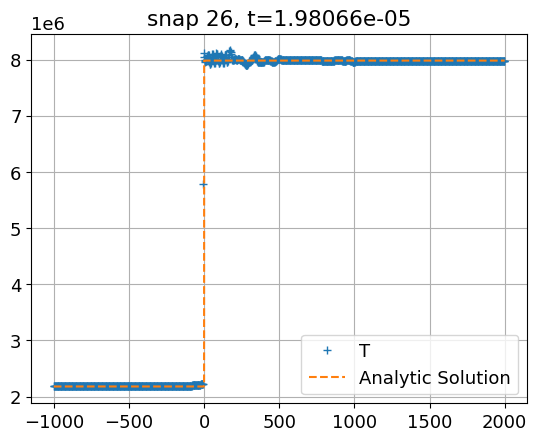

In [41]:
dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    if not i == num_of_snaps - 1: continue
    plt.plot(CMx[i, :], Tm[i, :], '+', label="T")
    plt.plot(x, sol['temperature'], '--', label="Analytic Solution")
    # plt.plot(CMx[i, :], Tr[i, :])

    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    # plt.xlim(0, 3.)
    plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    plt.show()
    plt.close()
    

In [21]:
output_files_path = "/home/itamarg/workspace/RICH/output/RadHydroMach2Multigroup_3"
path_to_initial_snap = path.join(output_files_path, f"Mach2_{0}.h5")

snaps = [file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))]
print(snaps)

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("Mach2") and (not file.endswith("final.h5"))])
num_groups = 0
num_cells = 0
num_ranks = 0

with h5py.File(path_to_initial_snap) as h5_file:
    print(h5_file["rank0"].keys())
    num_ranks = len([key for key in h5_file.keys() if "rank" in key])
    num_groups = len([key for key in h5_file["rank0"].keys() if "Eg" in key])
    num_cells = len(np.array(h5_file["rank0"]["Eg_0"]))

print(num_of_snaps, num_ranks, num_groups)    

['Mach2_0.h5', 'Mach2_2300.h5', 'Mach2_100.h5', 'Mach2_200.h5', 'Mach2_300.h5', 'Mach2_2400.h5', 'Mach2_400.h5', 'Mach2_500.h5', 'Mach2_2500.h5', 'Mach2_600.h5', 'Mach2_700.h5', 'Mach2_2600.h5', 'Mach2_800.h5', 'Mach2_900.h5', 'Mach2_2700.h5', 'Mach2_1000.h5', 'Mach2_1100.h5', 'Mach2_2800.h5', 'Mach2_1200.h5', 'Mach2_1300.h5', 'Mach2_1400.h5', 'Mach2_2900.h5', 'Mach2_1500.h5', 'Mach2_1600.h5', 'Mach2_3000.h5', 'Mach2_1700.h5', 'Mach2_1800.h5', 'Mach2_3100.h5', 'Mach2_1900.h5', 'Mach2_2000.h5', 'Mach2_3200.h5', 'Mach2_2100.h5', 'Mach2_2200.h5', 'Mach2_3300.h5', 'Mach2_3400.h5', 'Mach2_3500.h5', 'Mach2_3600.h5', 'Mach2_3700.h5', 'Mach2_3800.h5', 'Mach2_3900.h5', 'Mach2_4000.h5', 'Mach2_4100.h5', 'Mach2_4200.h5', 'Mach2_4300.h5', 'Mach2_4400.h5', 'Mach2_4500.h5', 'Mach2_4600.h5', 'Mach2_4700.h5', 'Mach2_4800.h5', 'Mach2_4900.h5', 'Mach2_5000.h5', 'Mach2_5100.h5', 'Mach2_5200.h5', 'Mach2_5300.h5', 'Mach2_5400.h5', 'Mach2_5500.h5', 'Mach2_5600.h5', 'Mach2_5700.h5', 'Mach2_5800.h5', 'Mach2_5

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161


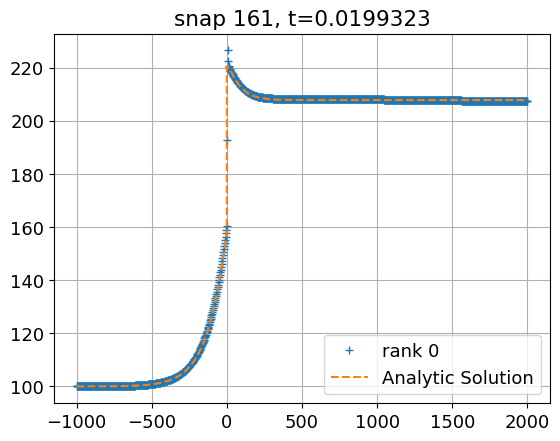

In [25]:
x = np.linspace(-1000, 2000, int(1e5))
sol = solver.solve_profiles(time=0.0, x=x)

dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)
for i in range(num_of_snaps):
    print(i)
    path_to_snap = path.join(output_files_path, f"Mach2_{i*100}.h5")
    time = None
    with h5py.File(path_to_snap) as h5_file:
        time = h5_file["Time"][0]
        if "rank0" not in h5_file.keys(): 
            plt.plot(np.array(h5_file["CMx"]), np.array(h5_file["Temperature"]), '+', label=f"rank 0")
        else :
            for j in range(num_ranks):
                plt.plot(np.array(h5_file[f"rank{j}"]["CMx"]), np.array(h5_file[f"rank{j}"]["Temperature"]), '+', label=f"rank {j}")
    plt.plot(x, sol['temperature'], '--', label="Analytic Solution")

    plt.title(f"snap {i}, t={time:g}")
    plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()
                


INFO:RadiativeShock:creating a RadiativeShock calculator...
INFO:RadiativeShock:gamma=1.66667
INFO:RadiativeShock:M0=3
INFO:RadiativeShock:P0=9.94089e-05
INFO:RadiativeShock:downstream (unshocked, left) state: rho=5.69[g/cc] T=2180000[K]=0.1878579[keV] v=5.19e+07[cm/s]
INFO:RadiativeShock:upstream   (shocked, right)  state: rho=17.08226[g/cc] T=7983031[K]=0.6879243[keV] v=1.712593e+07[cm/s]
INFO:RadiativeShock:v_shock=-242394[cm/s]
INFO:RadiativeShock:compression 3.00215
INFO:RadiativeShock:matter ideal gas (gamma=1.66667) dominated compression 3.0002
INFO:RadiativeShock:radiation ideal gas (gamma=4/3) dominated compression 4.33378
INFO:RadiativeShock:calculated mach=(v_shock-v_left)/cs_left=3 while given mach M0=3 err=3.33067e-16
INFO:NLTERadiativeShock:creating a NLTERadiativeShock calculator...


Precursor region
Relaxation region
Discontinuous case: embedded hydrodynamic shock


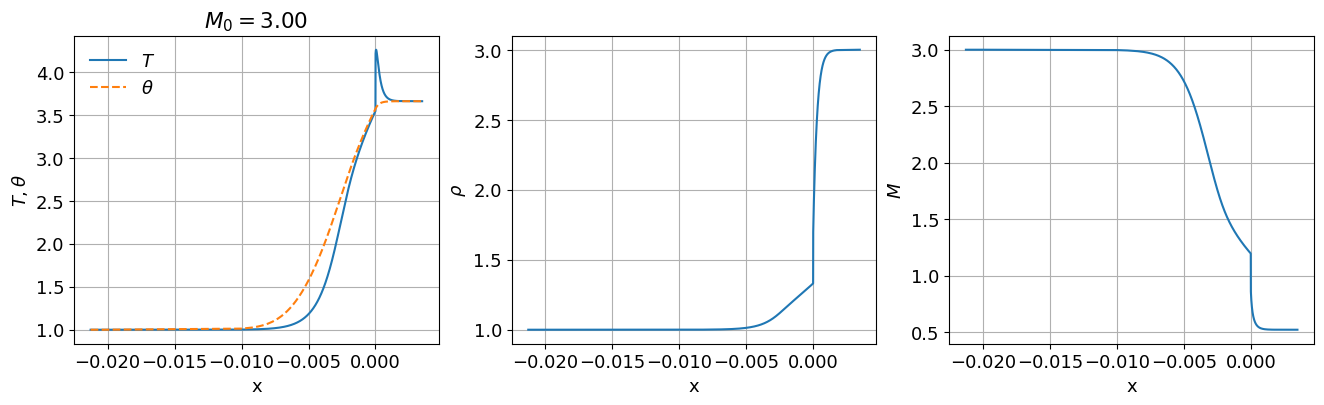

7983030.51154665 17.082261706361905 17125927.849233154 83144626.1815324 82673592.81437126


In [42]:
Navog = 6.02214076e23
k_boltz = 1.380649e-16
gas_constant = k_boltz*Navog
molar_mass_H = 1.
solver = NLTERadiativeShock(
    M0=3.,
    gamma=5./3.,
    sigma_ross=lambda T,rho:577.,
    sigma_abs=lambda T,rho:577.,
    cv=gas_constant/(5./3.-1.)/molar_mass_H,
    rho_left=5.69,
    v_left=5.19e7,
    T_left=2.18e6,
    plot_dimensionless=True,
    eps_nlte_solver=1e-6,
)

print(solver.T_right, solver.rho_right, solver.v_right, gas_constant, 1.380649E-16/1.67e-24)


NameError: name 'Units' is not defined